# Telco Customer Churn Dataset - ANN Project

## 1.Importing Libraries 

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## 2.Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\ksowm\Downloads\archive (5)\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f'Shape: {df.shape}')

Shape: (7043, 21)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Drop unnecessary columns
- Drop customerID — just an identifier

In [6]:
df.drop(columns = ['customerID'], inplace = True)
df.shape

(7043, 20)

### Fix TotalCharges Column

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df['TotalCharges'].dtype

dtype('float64')

### Convert Target Column

In [9]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [10]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
print(df['Churn'].unique())
print(df['Churn'].value_counts())

[0 1]
Churn
0    5174
1    1869
Name: count, dtype: int64


### Missing Values

In [11]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
TotalCharges    11
dtype: int64


In [12]:
df.dropna(inplace=True)
print(f'After dropna — remaining rows: {len(df)}')

After dropna — remaining rows: 7032


### Remove Duplicate 

In [13]:
print(f'Duplicates: {df.duplicated().sum()}')

Duplicates: 22


In [14]:
df.drop_duplicates(inplace=True)

In [18]:
# Categorical Colums
cat_cols = df.select_dtypes(include =['object']).columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [20]:
for col in cat_cols:
    print(f"{col}:",df[col].unique())

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### Convert binary columns

In [21]:
# Simplify redundant sub-categories
df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)

In [22]:
binary_cols = [
    'Partner','Dependents','PhoneService','MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({"Yes":1, "No":0})

In [23]:
df["gender"] = df["gender"].map({"Male":1, "Female":0})

In [24]:
for col in cat_cols:
    print(f"{col}:",df[col].unique())

gender: [0 1]
Partner: [1 0]
Dependents: [0 1]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [25]:
# One-Hot Encode multi-class categoricals

from sklearn.preprocessing import OneHotEncoder
obj_cols = ['InternetService', 'Contract', 'PaymentMethod']
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df[obj_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns = ohe.get_feature_names_out(obj_cols),
    index=df.index
)

df = df.drop(obj_cols, axis=1)
df = pd.concat([df, encoded_df], axis=1)

print(f'Final dataset shape: {df.shape}')
df.head()

Final dataset shape: (7010, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7010 non-null   int64  
 1   SeniorCitizen                          7010 non-null   int64  
 2   Partner                                7010 non-null   int64  
 3   Dependents                             7010 non-null   int64  
 4   tenure                                 7010 non-null   int64  
 5   PhoneService                           7010 non-null   int64  
 6   MultipleLines                          7010 non-null   int64  
 7   OnlineSecurity                         7010 non-null   int64  
 8   OnlineBackup                           7010 non-null   int64  
 9   DeviceProtection                       7010 non-null   int64  
 10  TechSupport                            7010 non-null   int64  
 11  Streaming

# Split the Data 

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn",axis =1)
y = df["Churn"]

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2, random_state = 42,stratify=y)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}')

Train: (5608, 23) | Test: (1402, 23)
Train churn rate: 26.50% | Test churn rate: 26.46%


# Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({0: 4122, 1: 1486})
After SMOTE: Counter({0: 4122, 1: 4122})


# Build ANN Model

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout , BatchNormalization

model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile Model

In [57]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 192 (768.00 B)

In [58]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

# Train Model

In [60]:
history = model.fit(
    X_train_smote, y_train_smote,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7662 - loss: 0.4682 - val_accuracy: 0.8623 - val_loss: 0.4448 - learning_rate: 2.5000e-04
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7794 - loss: 0.4594 - val_accuracy: 0.8296 - val_loss: 0.5045 - learning_rate: 2.5000e-04
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7786 - loss: 0.4581 - val_accuracy: 0.8229 - val_loss: 0.5051 - learning_rate: 2.5000e-04
Epoch 4/100
202/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7685 - loss: 0.4638
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7783 - loss: 0.4560 - val_accuracy: 0.7932 - val_loss: 0.5179 - learning_rate: 2.5000e-04
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7807 - loss: 0.4563 - val_accuracy: 0.7956 - val_loss: 0.5269 - learning_rate: 1.2500e-04
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy:

# Evaluate Model

In [63]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1031
           1       0.51      0.75      0.61       371

    accuracy                           0.75      1402
   macro avg       0.70      0.75      0.71      1402
weighted avg       0.79      0.75      0.76      1402

ROC-AUC: 0.7474947777914307


## Actual Training Curves — Loss & Accuracy

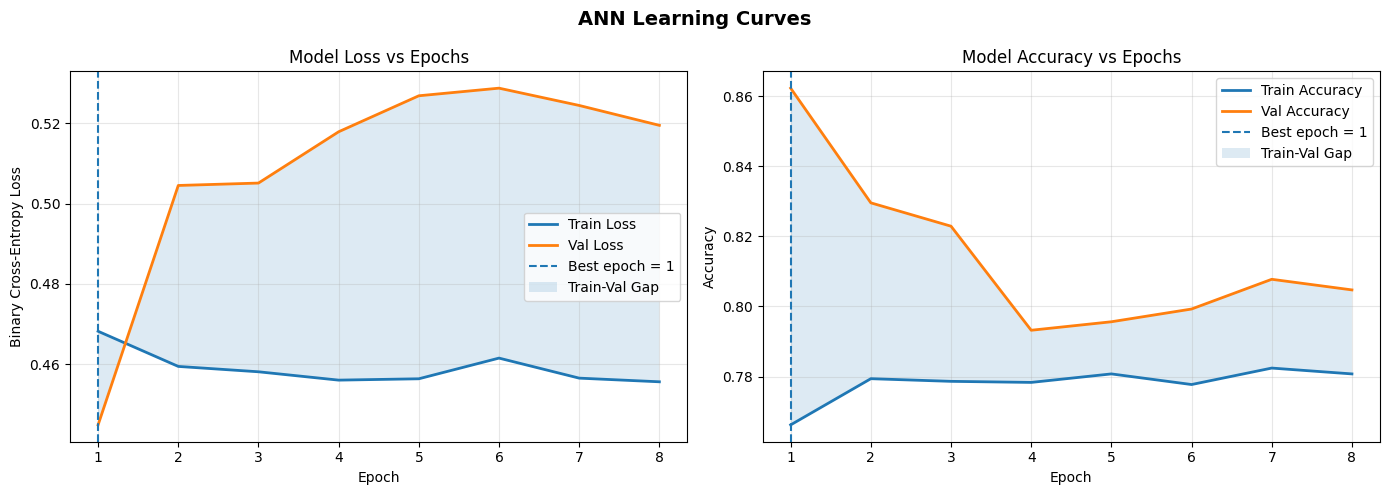

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Get metrics from history
# -----------------------------
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# -----------------------------
# Best epoch
# -----------------------------
best_epoch = np.argmin(val_loss) + 1

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# =====================================================
# LOSS CURVE
# =====================================================

axes[0].plot(epochs, train_loss,
             label='Train Loss',
             linewidth=2)

axes[0].plot(epochs, val_loss,
             label='Val Loss',
             linewidth=2)

# Best epoch line
axes[0].axvline(best_epoch,
                linestyle='--',
                label=f'Best epoch = {best_epoch}')

# Gap shading
axes[0].fill_between(
    epochs,
    train_loss,
    val_loss,
    alpha=0.15,
    label='Train-Val Gap'
)

axes[0].set_title('Model Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')

axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =====================================================
# ACCURACY CURVE
# =====================================================

axes[1].plot(epochs, train_acc,
             label='Train Accuracy',
             linewidth=2)

axes[1].plot(epochs, val_acc,
             label='Val Accuracy',
             linewidth=2)

# Best epoch line
axes[1].axvline(best_epoch,
                linestyle='--',
                label=f'Best epoch = {best_epoch}')

# Gap shading
axes[1].fill_between(
    epochs,
    train_acc,
    val_acc,
    alpha=0.15,
    label='Train-Val Gap'
)

axes[1].set_title('Model Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

axes[1].legend()
axes[1].grid(True, alpha=0.3)

# =====================================================
# Main Title
# =====================================================

fig.suptitle(
    'ANN Learning Curves',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


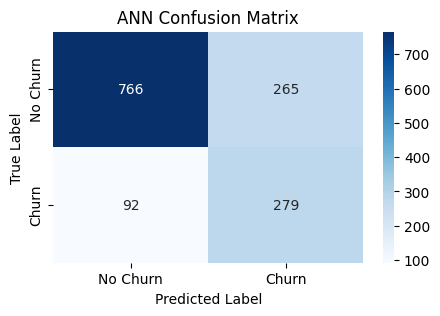

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------
# ANN Predictions
# ---------------------------------------
# Probabilities
y_prob_ann = model.predict(X_test)
# Convert to binary using threshold
y_pred_ann = (y_prob_ann > 0.5).astype(int)
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_ann)

# Plot

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ANN Confusion Matrix')
plt.show()

# ***Compare with ML Model***

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print('=' * 50)
print('Random Forest Classification Report')
print('=' * 50)
print(classification_report(y_test, rf_pred))


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.63      0.49      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.70      1402
weighted avg       0.78      0.79      0.78      1402



In [87]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
print('=' * 50)
print('XGBoost Classification Report')
print('=' * 50)
print(classification_report(y_test, xgb_pred))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1031
           1       0.58      0.50      0.54       371

    accuracy                           0.77      1402
   macro avg       0.70      0.68      0.69      1402
weighted avg       0.76      0.77      0.76      1402



## Combined ROC Curve
- (ANN + Random Forest + XGBoost)

In [92]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# ANN
y_prob_ann = model.predict(X_test).ravel()
# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
# XGBoost
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# ANN
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)
auc_ann = auc(fpr_ann, tpr_ann)

# ROC Curve Calculation
# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


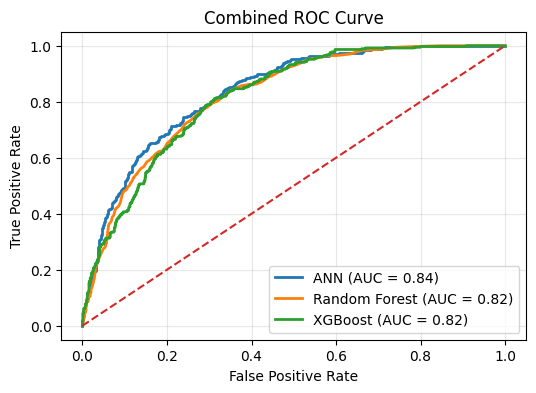

In [94]:
# Plot Combined ROC Curve
plt.figure(figsize=(6,4))

# ANN
plt.plot(fpr_ann,tpr_ann,linewidth=2,label=f'ANN (AUC = {auc_ann:.2f})')
# Random Forest
plt.plot(fpr_rf,tpr_rf,linewidth=2,label=f'Random Forest (AUC = {auc_rf:.2f})')
# XGBoost
plt.plot(fpr_xgb,tpr_xgb,linewidth=2,label=f'XGBoost (AUC = {auc_xgb:.2f})')

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Combined ROC Curve')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

## Combined Precision-Recall Curve

In [95]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# ANN
precision_ann, recall_ann, _ = precision_recall_curve(
    y_test,
    y_prob_ann
)

ap_ann = average_precision_score(y_test, y_prob_ann)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

ap_rf = average_precision_score(y_test, y_prob_rf)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

ap_xgb = average_precision_score(y_test, y_prob_xgb)

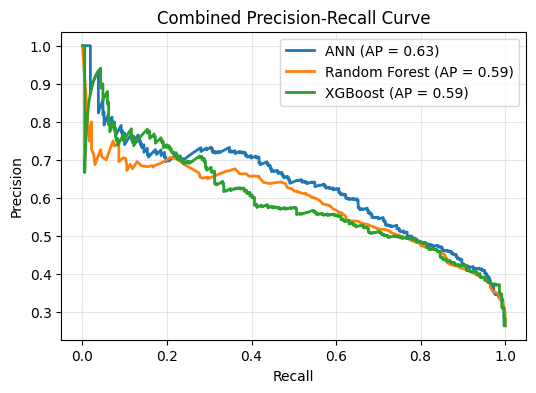

In [96]:
# Plot Combined Precision-Recall Curve
plt.figure(figsize=(6,4))

# ANN
plt.plot(
    recall_ann,
    precision_ann,
    linewidth=2,
    label=f'ANN (AP = {ap_ann:.2f})'
)

# Random Forest
plt.plot(
    recall_rf,
    precision_rf,
    linewidth=2,
    label=f'Random Forest (AP = {ap_rf:.2f})'
)

# XGBoost
plt.plot(
    recall_xgb,
    precision_xgb,
    linewidth=2,
    label=f'XGBoost (AP = {ap_xgb:.2f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Combined Precision-Recall Curve')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

## Model Summary Table

In [100]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# -------------------------------------------------
# Function to calculate metrics
# -------------------------------------------------

def get_metrics(y_true, y_pred, y_prob):

    return {

        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),

        'Precision': round(precision_score(y_true, y_pred), 4),

        'Recall':    round(recall_score(y_true, y_pred), 4),

        'F1-Score':  round(f1_score(y_true, y_pred), 4),

        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4)
    }

# -------------------------------------------------
# Create Results Table
# -------------------------------------------------

results = pd.DataFrame([

    {'Model': 'ANN',
     **get_metrics(y_test, y_pred_ann, y_prob_ann)},

    {'Model': 'Random Forest',
     **get_metrics(y_test, rf_pred, y_prob_rf )},

    {'Model': 'XGBoost',
     **get_metrics(y_test, xgb_pred, y_prob_xgb)}

]).set_index('Model')

# -------------------------------------------------
# Display Results
# -------------------------------------------------

print('\n📊 Model Comparison')
print('=' * 55)

print(results.to_string())

print(f'\nBest model by ROC-AUC : {results["ROC-AUC"].idxmax()}')

print(f'Best model by Recall  : {results["Recall"].idxmax()}')


📊 Model Comparison
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
ANN              0.7454     0.5129  0.7520    0.6098   0.8370
Random Forest    0.7874     0.6272  0.4852    0.5471   0.8218
XGBoost          0.7703     0.5759  0.5013    0.5360   0.8175

Best model by ROC-AUC : ANN
Best model by Recall  : ANN


In [102]:
import joblib
model.save('churn_ann_model.h5')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(ohe,    'ohe_encoder.pkl')
joblib.dump(rf,     'random_forest_model.pkl')
joblib.dump(xgb,    'xgboost_model.pkl')

print('All models and preprocessors saved ✅')
print('  churn_ann_model.h5')
print('  scaler.pkl | ohe_encoder.pkl')
print('  random_forest_model.pkl | xgboost_model.pkl')

All models and preprocessors saved ✅
  churn_ann_model.h5
  scaler.pkl | ohe_encoder.pkl
  random_forest_model.pkl | xgboost_model.pkl
